# Dataset Preparation for ML

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
from IPython.display import display
import pandas as pd

warnings.filterwarnings("ignore", message="IProgress not found.*")

from src.tensor_utils import (
    build_dataset_tensor_embedding_2d,
    build_moa_labeled_tensor_dataset,
    save_labeled_tensor_dataset,
    plot_tensor_embedding_2d,
)
from src.dataset_config import write_current_dataset_config
from src.dataset_naming import build_mechanism_filename_prefix

from src.notebook_utils import (
    configure_full_dataframe_display,
    load_compound_image_condition_map_csv,
)


In [2]:
configure_full_dataframe_display()

# Load the previously generated condition map snapshot instead of rebuilding it from the workbook and folders.
condition_df = load_compound_image_condition_map_csv()
condition_df.shape

(2376, 20)

## Alternative Mechanism Sets

These cells are optional presets for `selected_mechanisms` and `max_compounds_per_action`.
Run one of them if you want to try a different pair-vs-pair design before executing the main user-input cell.

### Alternative A: Balanced Excitatory vs Cholinergic Pairing

Reasoning:
- Pair 1 stays strongly excitatory: `GABAAR_Antagonist` vs `NMDAR_Activation`.
- Pair 2 is cholinergic: `AChE_Inhibitor_Reversible` vs `mAChR_Agonist_NonSelective`.
- This is a good compromise between mechanistic coherence and class size.
- All four mechanisms support `max_compounds_per_action = 3`.

In [3]:
selected_mechanisms_A = [
    "GABAAR_Antagonist",
    "NMDAR_Activation",
    "AChE_Inhibitor_Reversible",
    "mAChR_Agonist_NonSelective",
]
max_compounds_per_action_A = 3


### Alternative B: Stronger Between-Pair Separation

Reasoning:
- Pair 1 remains the excitatory pair: `GABAAR_Antagonist` vs `NMDAR_Activation`.
- Pair 2 becomes cholinergic/opioid-modulatory: `AChE_Inhibitor_Reversible` vs `DOR_Agonist`.
- This should create clearer between-pair separation in embeddings.
- All four mechanisms still support `max_compounds_per_action = 3`.

In [4]:
selected_mechanisms_B = [
    "GABAAR_Antagonist",
    "NMDAR_Activation",
    "AChE_Inhibitor_Reversible",
    "DOR_Agonist",
]
max_compounds_per_action_B = 3


### Alternative C: Closer to the Original GABA/NMDA Story

Reasoning:
- Pair 1 stays seizure-like: `GABAAR_Antagonist` vs `Kv_Blocker_NonSelective`.
- Pair 2 remains glutamatergic: `NMDAR_Activation` vs `NMDAR_Antagonist`.
- This is closer to the original idea while improving compound availability over the negative-allosteric GABAAR option.
- The limiting class count here is `2`, so `max_compounds_per_action = 2`.

In [5]:
selected_mechanisms_C = [
    "GABAAR_Antagonist",
    "Kv_Blocker_NonSelective",
    "NMDAR_Activation",
    "NMDAR_Antagonist",
]
max_compounds_per_action_C = 2


In [6]:
# User inputs
# selected_mechanisms:
#   list of normalized mechanism names from condition_df["mechanism_of_action"].
#   Use 2 or more classes depending on the comparison you want to study.
#   This default picks two similar pairs:
#   Pair 1: GABAAR_Antagonist vs GABAAR_NegativeAllostericModulator.
#   Pair 2: NMDAR_Activation vs NMDAR_Antagonist.
#   The goal is to create within-pair similarity but between-pair separation.
selected_mechanisms = selected_mechanisms_A
# selected_concentrations:
#   subset of treatment concentration bands to include.
#   Typical options: ["high"], ["mid"], ["low"], or combinations such as ["high", "mid", "low"].
#   Water controls are added separately as class 0 and do not need to be listed here.
selected_concentrations = ["high", "mid"]
# max_compounds_per_action:
#   maximum number of distinct compounds to keep for each mechanism class.
#   Use a small number for quick prototyping and a larger number for broader class coverage.
max_compounds_per_action = max_compounds_per_action_A
# max_tensors_per_compound:
#   maximum number of condition tensors to keep per compound after filtering.
#   Increase this to use more runs / folders per compound, decrease it to balance classes faster.
max_tensors_per_compound = 16
# output_size:
#   target tensor size as (T, Z, Y, X) after cached loading, downsampling, and drift correction.
#   Use None in any position to keep the source dimension unchanged.
#   Examples: (10, 1, 32, 32), (10, 3, 64, 64), (None, 1, 64, 64).
output_size = (20, 5, 64, 64)
# only_active:
#   True keeps only folders not marked do_not_use / inactive.
#   False also includes non-active folders when present in the condition map.
only_active = True
# normalize_global_drift:
#   True applies the LOESS-style global intensity drift correction during loading.
#   False keeps the raw intensity trend.
normalize_global_drift = True
# loess_frac:
#   smoothing fraction for the global intensity drift correction.
#   Smaller values follow local changes more closely; larger values smooth more aggressively.
#   Typical range: 0.1 to 0.4.
loess_frac = 0.25
# use_cache:
#   True reuses cached processed tensors from .tensor_cache when available.
#   False forces a rebuild from the source TIFFs.
use_cache = True
# use_tiff_cache:
#   True mirrors only the selected TIFF files into .tiff_cache before loading.
#   False reads directly from the mounted source paths.
use_tiff_cache = True
# embedding_method:
#   "pca" for a linear 2D projection, "umap" for a nonlinear neighborhood-preserving embedding.
embedding_method = "umap"
# umap_n_neighbors:
#   local neighborhood size for UMAP. Smaller values emphasize fine local structure,
#   larger values emphasize broader global structure.
umap_n_neighbors = 32
# umap_min_dist:
#   minimum spacing of points in the UMAP embedding.
#   Smaller values make tighter clusters, larger values spread clusters out more.
umap_min_dist = 0.1
# embedding_target:
#   target used for coloring and labeling the 2D embedding.
#   Use one of "mechanism", "compound", "concentration", or "control".
embedding_target = "mechanism"
# embedding_random_seed:
#   seed used for reproducible 2D embedding initialization.
embedding_random_seed = 0
# dataset_artifact_path:
#   relative path under .dataset_cache or an absolute path for the persisted dataset artifact.
#   By default this is constructed from the active dataset settings.
mechanism_prefix = build_mechanism_filename_prefix(selected_mechanisms)
output_size_tag = "_".join(
    f"{axis.lower()}{size if size is not None else 'full'}"
    for axis, size in zip(("T", "Z", "Y", "X"), output_size)
)
dataset_artifact_path = (
    f"moa_{mechanism_prefix}_"
    f"c{len(selected_concentrations)}_"
    f"mca{max_compounds_per_action}_"
    f"mtc{max_tensors_per_compound}_"
    f"{output_size_tag}.pt"
)
dataset_artifact_path

'moa_GA_An_NM_Ac_AC_In_mA_Ag_c2_mca3_mtc16_t20_z5_y64_x64.pt'

In [7]:
%%time
dataset = build_moa_labeled_tensor_dataset(
    condition_df=condition_df,
    selected_mechanisms=selected_mechanisms,
    selected_concentrations=selected_concentrations,
    max_compounds_per_action=max_compounds_per_action,
    max_tensors_per_compound=max_tensors_per_compound,
    output_size=output_size,
    only_active=only_active,
    normalize_global_drift=normalize_global_drift,
    loess_frac=loess_frac,
    use_cache=use_cache,
    use_tiff_cache=use_tiff_cache,
)

[2026-04-14 20:24:40] [002/283] kind=treatment source=source_fs    conc=high     elapsed=00:00 eta=00:38 mechanism=GABAAR_Antagonist compound=Bemegride
[2026-04-14 20:25:02] [003/283] kind=treatment source=source_fs    conc=high     elapsed=00:22 eta=51:26 mechanism=GABAAR_Antagonist compound=Bemegride
[2026-04-14 20:25:24] [004/283] kind=treatment source=source_fs    conc=high     elapsed=00:44 eta=1:07:55 mechanism=GABAAR_Antagonist compound=Bemegride
[2026-04-14 20:25:46] [005/283] kind=treatment source=source_fs    conc=high     elapsed=01:05 eta=1:16:00 mechanism=GABAAR_Antagonist compound=Bemegride
[2026-04-14 20:26:08] [006/283] kind=treatment source=source_fs    conc=high     elapsed=01:28 eta=1:21:35 mechanism=GABAAR_Antagonist compound=Bemegride
[2026-04-14 20:26:31] [007/283] kind=treatment source=source_fs    conc=high     elapsed=01:51 eta=1:25:28 mechanism=GABAAR_Antagonist compound=Bemegride
[2026-04-14 20:26:55] [008/283] kind=treatment source=source_fs    conc=high    

<tifffile.TiffPages @16> invalid page offset 7002616
<tifffile.TiffPages @16> invalid page offset 7002616


[2026-04-14 22:26:24] [082/283] kind=treatment source=source_fs    conc=mid      elapsed=2:01:43 eta=5:03:34 mechanism=NMDAR_Activation compound=(RS)-(Tetrazol-5-yl)glycine
[2026-04-14 22:29:18] [083/283] kind=treatment source=source_fs    conc=mid      elapsed=2:04:38 eta=5:05:30 mechanism=NMDAR_Activation compound=(RS)-(Tetrazol-5-yl)glycine
[2026-04-14 22:32:17] [084/283] kind=treatment source=source_fs    conc=mid      elapsed=2:07:37 eta=5:07:30 mechanism=NMDAR_Activation compound=(RS)-(Tetrazol-5-yl)glycine
[2026-04-14 22:35:19] [085/283] kind=control   source=source_fs    conc=control  elapsed=2:10:39 eta=5:09:30 mechanism=NMDAR_Activation compound=(RS)-(Tetrazol-5-yl)glycine
[2026-04-14 22:38:27] [086/283] kind=control   source=source_fs    conc=control  elapsed=2:13:47 eta=5:11:38 mechanism=NMDAR_Activation compound=(RS)-(Tetrazol-5-yl)glycine
[2026-04-14 22:41:38] [087/283] kind=control   source=source_fs    conc=control  elapsed=2:16:58 eta=5:13:44 mechanism=NMDAR_Activation

/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/ZebraFish/src/tensor_utils.py:1149: UserWarning: Failed to build treatment tensor dataset example for mechanism='NMDAR_Activation', compound='N-methyl-D-aspartate', concentration_band='mid', image_condition_dir='/mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/SECOND BATCH convulsants/NMDA 16 Dec 2016/1mM F1.5'. Skipping this example. Root cause: FileNotFoundError('No TIFF files found under /mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/SECOND BATCH convulsants/NMDA 16 Dec 2016/1mM F1.5')
  warnings.warn(f"{message}. Skipping this example. Root cause: {exc!r}")


[2026-04-15 03:45:00] [130/283] kind=treatment source=source_fs    conc=mid      elapsed=7:20:20 eta=8:45:40 mechanism=NMDAR_Activation compound=N-methyl-D-aspartate


...

[2026-04-16 00:37:14] [238/283] kind=treatment source=source_fs    conc=high     elapsed=28:12:33 eta=5:28:31 mechanism=mAChR_Agonist_NonSelective compound=Muscarine
[2026-04-16 01:02:39] [239/283] kind=treatment source=source_fs    conc=high     elapsed=28:37:58 eta=5:24:50 mechanism=mAChR_Agonist_NonSelective compound=Muscarine
[2026-04-16 01:26:55] [240/283] kind=treatment source=source_fs    conc=high     elapsed=29:02:15 eta=5:20:45 mechanism=mAChR_Agonist_NonSelective compound=Muscarine
[2026-04-16 01:35:43] [241/283] kind=treatment source=source_fs    conc=high     elapsed=29:11:03 eta=5:13:44 mechanism=mAChR_Agonist_NonSelective compound=Muscarine
[2026-04-16 01:44:33] [242/283] kind=treatment source=source_fs    conc=high     elapsed=29:19:53 eta=5:06:42 mechanism=mAChR_Agonist_NonSelective compound=Muscarine
[2026-04-16 01:53:23] [243/283] kind=treatment source=source_fs    conc=mid      elapsed=29:28:42 eta=4:59:39 mechanism=mAChR_Agonist_NonSelective compound=Muscarine
[202

/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/ZebraFish/src/tensor_utils.py:1189: UserWarning: Failed to build control tensor dataset example for compound='Muscarine', image_condition_dir='/mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/FOURTH BATCH 2018/Muscarine Run 2 16 April 2018/Water f2.1 funny angle'. Skipping this example. Root cause: OSError(112, 'Host is down')
  warnings.warn(f"{message}. Skipping this example. Root cause: {exc!r}")


[2026-04-16 04:21:45] [259/283] kind=treatment source=source_fs    conc=high     elapsed=31:57:05 eta=3:05:46 mechanism=mAChR_Agonist_NonSelective compound=Pilocarpine


<tifffile.TiffPages @16> invalid page offset 7002616
<tifffile.TiffPages @16> invalid page offset 7002616


[2026-04-16 04:38:31] [260/283] kind=treatment source=source_fs    conc=high     elapsed=32:13:51 eta=2:59:12 mechanism=mAChR_Agonist_NonSelective compound=Pilocarpine
[2026-04-16 04:51:37] [261/283] kind=treatment source=source_fs    conc=high     elapsed=32:26:57 eta=2:52:14 mechanism=mAChR_Agonist_NonSelective compound=Pilocarpine
[2026-04-16 05:08:27] [262/283] kind=treatment source=source_fs    conc=high     elapsed=32:43:47 eta=2:45:32 mechanism=mAChR_Agonist_NonSelective compound=Pilocarpine
[2026-04-16 05:24:22] [263/283] kind=treatment source=source_fs    conc=high     elapsed=32:59:42 eta=2:38:41 mechanism=mAChR_Agonist_NonSelective compound=Pilocarpine
[2026-04-16 05:38:19] [264/283] kind=treatment source=source_fs    conc=high     elapsed=33:13:39 eta=2:31:36 mechanism=mAChR_Agonist_NonSelective compound=Pilocarpine
[2026-04-16 05:58:04] [265/283] kind=treatment source=source_fs    conc=high     elapsed=33:33:24 eta=2:24:54 mechanism=mAChR_Agonist_NonSelective compound=Pilo

In [8]:
saved_dataset_path = save_labeled_tensor_dataset(dataset, dataset_artifact_path)
current_dataset_config_path = write_current_dataset_config(saved_dataset_path)
saved_dataset_path, current_dataset_config_path

(PosixPath('/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/ZebraFish/.dataset_cache/moa_GA_An_NM_Ac_AC_In_mA_Ag_c2_mca3_mtc16_t20_z5_y64_x64.pt'),
 PosixPath('/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/ZebraFish/artifacts/current_dataset.json'))

In [9]:
summary_df = pd.DataFrame(
    [
        {"metric": "n_examples", "value": int(dataset["tensors"].shape[0])},
        {"metric": "tensor_shape", "value": str(tuple(dataset["tensors"].shape))},
        {"metric": "mechanism_label_tensor_shape", "value": str(tuple(dataset["labels"].shape))},
        {"metric": "compound_label_tensor_shape", "value": str(tuple(dataset["compound_labels"].shape))},
        {"metric": "concentration_label_tensor_shape", "value": str(tuple(dataset["concentration_labels"].shape))},
        {"metric": "is_control_tensor_shape", "value": str(tuple(dataset["is_control"].shape))},
        {"metric": "timepoints_per_tensor", "value": int(dataset["tensors"].shape[1])},
        {"metric": "z_slices_per_tensor", "value": int(dataset["tensors"].shape[2])},
        {"metric": "image_height", "value": int(dataset["tensors"].shape[3])},
        {"metric": "image_width", "value": int(dataset["tensors"].shape[4])},
        {"metric": "n_mechanism_classes_including_water", "value": int(len(dataset["label_map"]))},
        {"metric": "n_compound_classes_including_control", "value": int(len(dataset["compound_label_map"]))},
        {"metric": "n_concentration_classes_including_control", "value": int(len(dataset["concentration_label_map"]))},
    ]
)

mechanism_label_map_df = pd.DataFrame(
    [{"label": label, "class_name": class_name} for label, class_name in dataset["label_map"].items()]
).sort_values("label").reset_index(drop=True)
compound_label_map_df = pd.DataFrame(
    [{"label": label, "compound_name": class_name} for label, class_name in dataset["compound_label_map"].items()]
).sort_values("label").reset_index(drop=True)
concentration_label_map_df = pd.DataFrame(
    [{"label": label, "concentration_name": class_name} for label, class_name in dataset["concentration_label_map"].items()]
).sort_values("label").reset_index(drop=True)

display(summary_df)
display(mechanism_label_map_df)
display(compound_label_map_df)
display(concentration_label_map_df)

,metric,value
0,n_examples,279
1,tensor_shape,"(279, 20, 5, 64, 64)"
2,mechanism_label_tensor_shape,"(279,)"
3,compound_label_tensor_shape,"(279,)"
4,concentration_label_tensor_shape,"(279,)"
5,is_control_tensor_shape,"(279,)"
6,timepoints_per_tensor,20
7,z_slices_per_tensor,5
8,image_height,64
9,image_width,64


,label,class_name
0,0,Water
1,1,GABAAR_Antagonist
2,2,NMDAR_Activation
3,3,AChE_Inhibitor_Reversible
4,4,mAChR_Agonist_NonSelective


,label,compound_name
0,0,Control
1,1,Bemegride
2,2,Bicuculline
3,3,Gabazine
4,4,(RS)-(Tetrazol-5-yl)glycine
5,5,Cis-ACPD
6,6,N-methyl-D-aspartate
7,7,Donepezil
8,8,Galantamine
9,9,Phenserine


,label,concentration_name
0,0,control
1,1,high
2,2,mid


In [10]:
display(dataset["metadata"].head(5))
display(dataset["metadata"].groupby(["label", "label_name"]).size().reset_index(name="n_examples"))
display(dataset["metadata"].groupby(["compound_label", "compound_label_name"]).size().reset_index(name="n_examples"))
display(dataset["metadata"].groupby(["concentration_label_id", "concentration_label_name"]).size().reset_index(name="n_examples"))

,original_instance_id,label,compound_label,compound_label_name,concentration_label_id,concentration_label_name,label_name,mechanism_of_action,compound,concentration_band,concentration_label,image_condition_dir,is_control
0,0,1,1,Bemegride,1,high,GABAAR_Antagonist,GABAAR_Antagonist,Bemegride,high,1 mM,/mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/THIRD BATCH convulsants/Bemegride run 1 1 June 17/1mM F1,False
1,1,1,1,Bemegride,1,high,GABAAR_Antagonist,GABAAR_Antagonist,Bemegride,high,1 mM,/mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/THIRD BATCH convulsants/Bemegride run 1 1 June 17/1mM F2,False
2,2,1,1,Bemegride,1,high,GABAAR_Antagonist,GABAAR_Antagonist,Bemegride,high,1 mM,/mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/THIRD BATCH convulsants/Bemegride run 1 1 June 17/1mM F3,False
3,3,1,1,Bemegride,1,high,GABAAR_Antagonist,GABAAR_Antagonist,Bemegride,high,1 mM,/mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/THIRD BATCH convulsants/Bemegride run 1 1 June 17/1mM F6,False
4,4,1,1,Bemegride,1,high,GABAAR_Antagonist,GABAAR_Antagonist,Bemegride,high,1 mM,/mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/THIRD BATCH convulsants/Bemegride run 2 7 6 17/1mM F2.1,False


,label,label_name,n_examples
0,0,Water,97
1,1,GABAAR_Antagonist,46
2,2,NMDAR_Activation,42
3,3,AChE_Inhibitor_Reversible,47
4,4,mAChR_Agonist_NonSelective,47


,compound_label,compound_label_name,n_examples
0,0,Control,97
1,1,Bemegride,16
2,2,Bicuculline,15
3,3,Gabazine,15
4,4,(RS)-(Tetrazol-5-yl)glycine,13
5,5,Cis-ACPD,15
6,6,N-methyl-D-aspartate,14
7,7,Donepezil,16
8,8,Galantamine,16
9,9,Phenserine,15


,concentration_label_id,concentration_label_name,n_examples
0,0,control,97
1,1,high,97
2,2,mid,85


In [11]:
# Reduce the persisted dataset tensors to 2D for quick inspection by the chosen target.
embedding_df = build_dataset_tensor_embedding_2d(
    dataset,
    target=embedding_target,
    method=embedding_method,
    random_state=embedding_random_seed,
    umap_n_neighbors=umap_n_neighbors,
    umap_min_dist=umap_min_dist,
)
display(embedding_df.head(5))

,embed_x,embed_y,label,label_name,method,original_instance_id,compound_label,compound_label_name,concentration_label_id,concentration_label_name,mechanism_of_action,compound,concentration_band,concentration_label,image_condition_dir,is_control,target
0,7.326306,0.901706,1,GABAAR_Antagonist,umap,0,1,Bemegride,1,high,GABAAR_Antagonist,Bemegride,high,1 mM,/mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/THIRD BATCH convulsants/Bemegride run 1 1 June 17/1mM F1,False,mechanism
1,9.525449,-0.184818,1,GABAAR_Antagonist,umap,1,1,Bemegride,1,high,GABAAR_Antagonist,Bemegride,high,1 mM,/mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/THIRD BATCH convulsants/Bemegride run 1 1 June 17/1mM F2,False,mechanism
2,6.466166,-1.615721,1,GABAAR_Antagonist,umap,2,1,Bemegride,1,high,GABAAR_Antagonist,Bemegride,high,1 mM,/mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/THIRD BATCH convulsants/Bemegride run 1 1 June 17/1mM F3,False,mechanism
3,7.967180,0.625895,1,GABAAR_Antagonist,umap,3,1,Bemegride,1,high,GABAAR_Antagonist,Bemegride,high,1 mM,/mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/THIRD BATCH convulsants/Bemegride run 1 1 June 17/1mM F6,False,mechanism
4,8.410295,-3.925578,1,GABAAR_Antagonist,umap,4,1,Bemegride,1,high,GABAAR_Antagonist,Bemegride,high,1 mM,/mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/THIRD BATCH convulsants/Bemegride run 2 7 6 17/1mM F2.1,False,mechanism


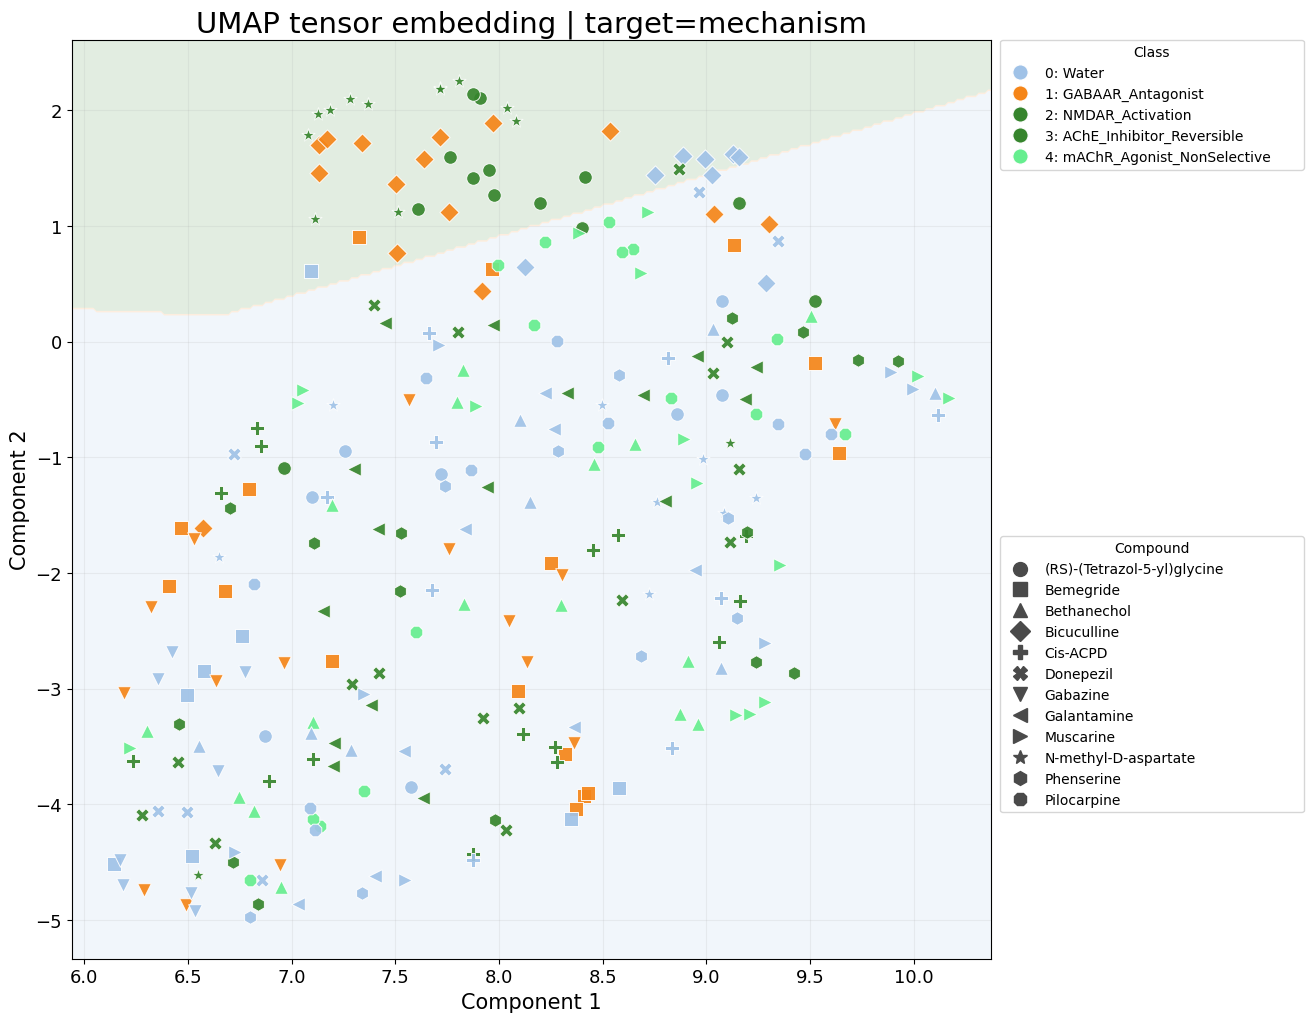

In [12]:
plot_tensor_embedding_2d(
    embedding_df,
    title=f"{embedding_method.upper()} tensor embedding | target={embedding_target}",
    show_svm_background=True,
);